# 🏥 CariSurg MedTech Pathways — Week 0, Tutorial 3
# Week 0 Day 3: Basic Data Visualization with Matplotlib

## Mercer General Hospital | Clinical AI & Innovation Unit

This notebook documents my Day 3 visualization task for the Week 0 emergency triage dataset. The goal is to create clinically meaningful plots using `matplotlib`. Each plot should answer a specific clinical or data question rather than simply display values.

## Purpose of Data Visualization

Data visualization helps identify patterns, distributions, relationships, and possible outliers in clinical data. In this task, the plots are used to better understand the cleaned triage dataset and support clinical interpretation.

## Key Matplotlib Concepts Used

The main plotting library used in this notebook is:

```python
import matplotlib.pyplot as plt


## 1. Setup — Load and Clean

**[TUTOR NOTE]**
Rather than repeating the cleaning steps live, run this setup block at the start.
Explain that in a real project, cleaning would live in a separate script (we will do this in Week 8).
For now, we consolidate it here so visualisation is the focus.


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'

# Mount your Google Drive so files are accessible from Colab
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")
FILE_PATH = '/content/drive/MyDrive/Carisurg Portfolio/Week 0/Data/EmergencyTriageDataset_Reduced_Dirty.csv'
df = pd.read_csv(FILE_PATH)

# ── Apply all cleaning from Days 1 & 2 ───────────────────────

# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!
Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


## 2. Why Visualise?

**Visualization Content**

A table of numbers is hard to reason about. A plot reveals patterns instantly.

In clinical data science, visualisation serves three purposes:
1. **Quality check** — does the data look like what we expect?
2. **Pattern discovery** — are there relationships between variables?
3. **Communication** — can a nurse or doctor understand our finding in 10 seconds?

The rule for this programme: **every plot must answer a specific clinical question.**
If you cannot state the question, you should not make the plot.


### **Matplotlib Fundamentals**

I included this section to document the basic plotting structure before applying it to the cleaned triage dataset.

#### **Basic Plot Structure**

Most matplotlib plots follow the same general structure:

```python
plt.figure(figsize=(8, 5))

# plotting code goes here

plt.title("Clear plot title")
plt.xlabel("X-axis label")
plt.ylabel("Y-axis label")

plt.tight_layout()
plt.savefig("plot_name.png", dpi=100, bbox_inches="tight")
plt.show()
```

Each part has a purpose:

- `plt.figure(figsize=(8, 5))` creates a new plot and controls the size.
- `plt.title()` adds a title so the reader knows what the plot is showing.
- `plt.xlabel()` labels the x-axis.
- `plt.ylabel()` labels the y-axis.
- `plt.tight_layout()` adjusts the spacing so labels are not cut off.
- `plt.savefig()` saves the plot as an image file.
- `plt.show()` displays the plot in the notebook.

#### **Why Labels Matter**

For clinical data, labels are important because the reader needs to know exactly what is being measured. Where possible, units should be included.

Examples:

- `MAP (mmHg)`
- `SBP (mmHg)`
- `DBP (mmHg)`
- `Pulse (bpm)`
- `Temperature (°C)`
- `Respiratory Rate (breaths/min)`

A plot without proper labels may be difficult to interpret, even if the code runs correctly.

## 3. Bar Plots — Categorical Columns

Bar plots are used to display counts or comparisons across categories. They are useful when the data is not continuous, but grouped into labels such as gender, triage category, arrival mode, or clinical flags.

In a clinical dataset, bar plots can help answer questions such as:

- How many patients fall into each triage level?
- Which arrival mode is most common?
- How many patients were flagged for clinical review?
- What is the distribution of patients by gender?

For a bar plot, the x-axis usually shows the categories, while the y-axis shows the count or frequency of each category.

A basic bar plot structure is:

```python
category_counts = df["Column_Name"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(category_counts.index, category_counts.values)

plt.title("Title of Bar Plot")
plt.xlabel("Category")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.savefig("bar_plot.png", dpi=100, bbox_inches="tight")
plt.show()

**Clinical question: What is the gender breakdown of patients in this dataset?**

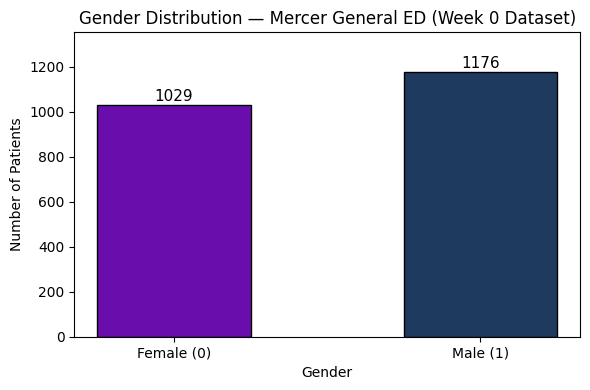

Saved: gender_distribution.png


In [44]:
# Bar plot: Gender distribution
fig, ax = plt.subplots(figsize=(6, 4))    # Create a new figure with width 6 inches and height 4 inches


counts = df['Gender'].value_counts().sort_index()     # Counts the unique genders that exist and sorts it based on the index
bars = ax.bar(['Female (0)', 'Male (1)'], counts.values,
              color=['#6A0DAD', '#1F3A5F'], edgecolor='black', width=0.5)

# Add count labels on top of each bar
for bar, count in zip(bars, counts.values):     # Zip function just pairs values from two/more lists/columns
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=11)        # Just finds the center of the bars and place the texts a little above bars

ax.set_title('Gender Distribution — Mercer General ED (Week 0 Dataset)', fontsize=12)
ax.set_xlabel('Gender')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, counts.max() * 1.15)      # Set the y-axis to start at 0 and end slightly above the tallest bar.

plt.tight_layout()
plt.savefig('gender_distribution.png', dpi=100, bbox_inches='tight')    # `dpi=100` controls the resolution of the saved image, while `bbox_inches="tight"` prevents labels or titles from being cut off.
plt.show()
print("Saved: gender_distribution.png")

### Bar Plot Interpretation

The gender distribution appears clinically plausible because both main gender categories are represented and the counts are not extremely one-sided. This is reasonable for an emergency department triage dataset, where patients are expected to come from a broad general population.

I also checked whether the categories shown in the plot matched the cleaned gender values and whether the total count was consistent with the dataset size. This helps confirm that the visualization is not only readable, but also reasonable based on the cleaned data.

## 4. Histograms — Distributions

Histograms are used to show the distribution of a numeric variable. They help us understand how values are spread across the dataset and whether most patients fall within a normal, low, or high range.

In a clinical dataset, histograms can help answer questions such as:

- What range of values is most common?
- Are most patients clustered around a normal range?
- Are there unusually low or high values?
- Does the variable appear skewed?
- Are there possible outliers that need clinical review?

For example, a histogram of `MAP` can show whether most patients have mean arterial pressure values within the expected range, and whether there are very low values that may suggest poor blood perfusion.

A basic histogram structure is:

```python
plt.figure(figsize=(8, 5))

plt.hist(df["MAP"].dropna(), bins=20, edgecolor="black")

plt.title("Distribution of Mean Arterial Pressure")
plt.xlabel("MAP (mmHg)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.savefig("map_histogram.png", dpi=100, bbox_inches="tight")
plt.show()

**Clinical question: How are Glasgow Coma Scale (GCS) scores distributed across our patients — are most patients alert, or are there many with reduced consciousness?**

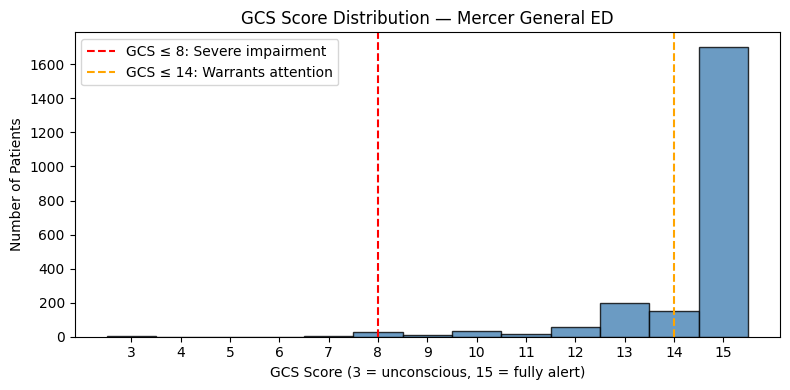

Saved: gcs_histogram.png


In [45]:
# Histogram: GCS distribution
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['GCS'], bins=range(3, 17), edgecolor='black',
        color='steelblue', alpha=0.8, align='left')

# Add a vertical line at the clinical threshold for severe impairment
ax.axvline(x=8, color='red', linestyle='--', linewidth=1.5,
           label='GCS ≤ 8: Severe impairment')
ax.axvline(x=14, color='orange', linestyle='--', linewidth=1.5,
           label='GCS ≤ 14: Warrants attention')

ax.set_title('GCS Score Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('GCS Score (3 = unconscious, 15 = fully alert)')
ax.set_ylabel('Number of Patients')
ax.set_xticks(range(3, 16))
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('gcs_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: gcs_histogram.png")

The vertical reference lines carry clinical meaning, illustrating the thresholds.
GCS ≤ 8 is the threshold for intubation consideration in many protocols.
GCS ≤ 14 triggers additional monitoring at Mercer.

**What does it tell us that most patients cluster at 15?**

It suggests most patients arriving at this ED are conscious which is consistent with a mixed-acuity emergency department.


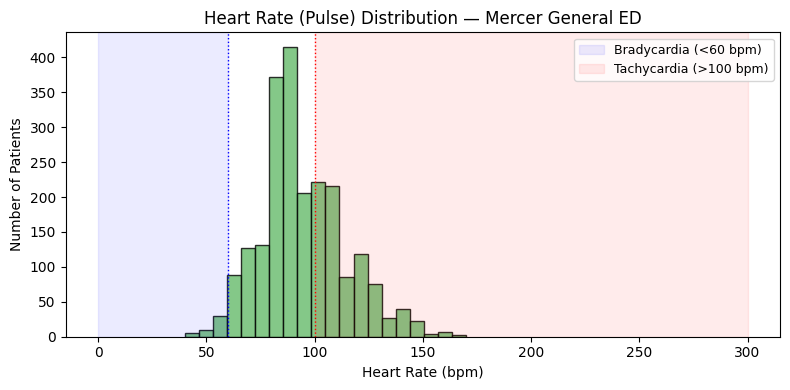

Saved: pulse_histogram.png


In [46]:
# Histogram: Pulse (heart rate) distribution
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['pulse'], bins=20, edgecolor='black', color='#66BB6A', alpha=0.8)

# Clinical reference zones
ax.axvspan(0, 60, alpha=0.08, color='blue', label='Bradycardia (<60 bpm)')
ax.axvspan(100, 300, alpha=0.08, color='red', label='Tachycardia (>100 bpm)')
ax.axvline(x=60, color='blue', linestyle=':', linewidth=1)
ax.axvline(x=100, color='red', linestyle=':', linewidth=1)

ax.set_title('Heart Rate (Pulse) Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('Heart Rate (bpm)')
ax.set_ylabel('Number of Patients')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('pulse_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: pulse_histogram.png")

NB: Tachy (Tachycardia): A resting heart rate that is too fast, generally over \(100\) beats per minute (bpm) in adults.Brady (Bradycardia): A resting heart rate that is too slow, generally under \(60\) bpm.

## 5. Scatter Plots — Two-Variable Relationships

Scatter plots are used to explore the relationship between two numeric variables. Each point on the graph represents one patient, with one variable plotted on the x-axis and the other plotted on the y-axis.

In clinical data, scatter plots can help answer questions such as:

- Do two vital signs increase together?
- Is there a visible relationship between two measurements?
- Are there unusual patient values that need review?
- Does the relationship make clinical sense?

For this dataset, a useful scatter plot is `SBP` versus `DBP`.

`SBP` stands for systolic blood pressure, which is the pressure in the arteries when the heart beats. `DBP` stands for diastolic blood pressure, which is the pressure in the arteries when the heart rests between beats.

SBP is usually higher than DBP. These two values are related because they both describe blood pressure, the relationship is shown in the MAP formula:

`MAP = (SBP + 2 × DBP) / 3`

This is because the heart spends more time in diastole than systole. Therefore, when interpreting blood pressure-related plots, both SBP and DBP are important.

A scatter plot of `SBP` and `DBP` can help show whether patients with higher systolic blood pressure also tend to have higher diastolic blood pressure. It can also help identify unusual combinations, such as very high SBP with very low DBP, which may need clinical review.

Normal readings are: 120 for systolic and 80 for diastolic

**Clinical question: Is there a relationship between systolic and diastolic blood pressure in these patients? Does it follow what physiology would predict?**

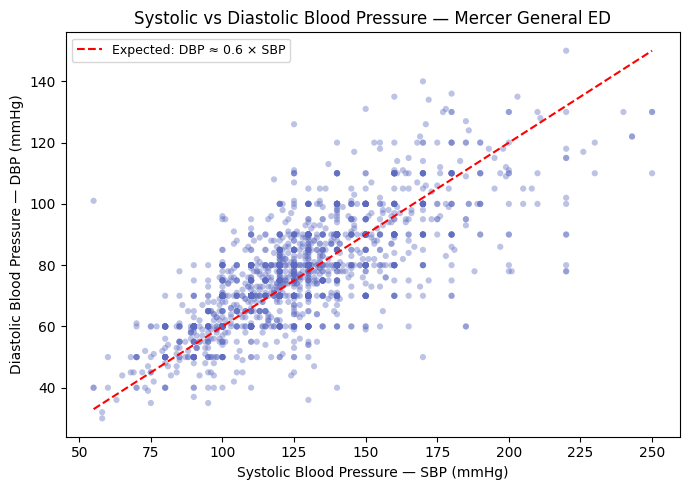

Saved: sbp_vs_dbp.png


In [47]:
# Scatter plot: SBP vs DBP
fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(df['SBP'], df['DBP'],
                     alpha=0.4, s=20, color='#5C6BC0', edgecolors='none')

# Add a trend reference: DBP is typically ~2/3 of SBP
sbp_range = np.linspace(df['SBP'].min(), df['SBP'].max(), 100)
ax.plot(sbp_range, sbp_range * 0.6, color='red', linestyle='--',
        linewidth=1.5, label='Expected: DBP ≈ 0.6 × SBP')

ax.set_title('Systolic vs Diastolic Blood Pressure — Mercer General ED', fontsize=12)
ax.set_xlabel('Systolic Blood Pressure — SBP (mmHg)')
ax.set_ylabel('Diastolic Blood Pressure — DBP (mmHg)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('sbp_vs_dbp.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: sbp_vs_dbp.png")

### Scatter Plot Interpretation

The scatter plot shows the relationship between systolic blood pressure (`SBP`) and diastolic blood pressure (`DBP`). Overall, the points show a general upward pattern, meaning patients with higher SBP often tend to have higher DBP as well.

The dashed reference line gives a rough comparison point, but the data does not have to follow it perfectly. DBP is not always exactly `0.6 × SBP`, because blood pressure varies between patients depending on clinical condition, age, medication use, stress, pain, cardiovascular status, and measurement context.

The deviations from the line are still useful. Some may represent normal clinical variation, while more extreme points could suggest unusual patient presentations or values that may need review. Since the scatter plot is not completely random, it supports the idea that SBP and DBP are related, while also showing that the relationship is not fixed for every patient.


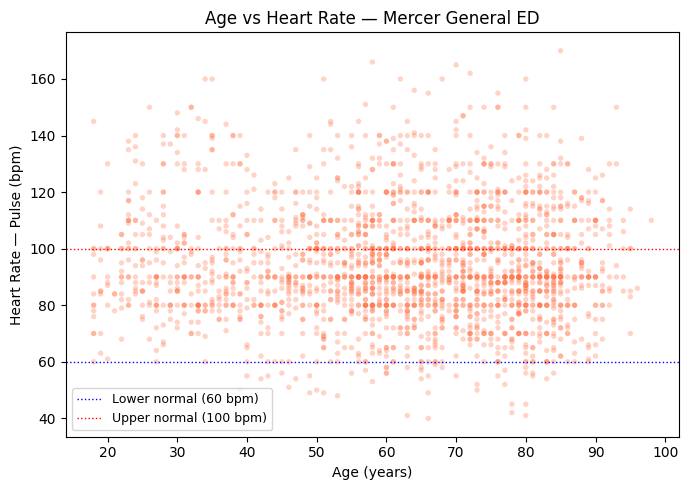

Saved: age_vs_pulse.png


In [48]:
# Scatter plot: Age vs Pulse — does age affect resting heart rate in ED patients?
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df['Age'], df['pulse'],
           alpha=0.3, s=15, color='#FF7043', edgecolors='none')

ax.set_title('Age vs Heart Rate — Mercer General ED', fontsize=12)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Heart Rate — Pulse (bpm)')

# Add clinical reference lines
ax.axhline(y=60, color='blue', linestyle=':', linewidth=1, label='Lower normal (60 bpm)')
ax.axhline(y=100, color='red', linestyle=':', linewidth=1, label='Upper normal (100 bpm)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('age_vs_pulse.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: age_vs_pulse.png")

## 6. Box Plots — Spotting Remaining Outliers

Box plots are used to summarize the spread of a numeric variable and identify possible outliers. They are useful after cleaning because they help check whether unusual values still remain in the dataset.

A box plot shows:

- The median value
- The middle 50% of the data
- The general spread of the values
- Possible outliers beyond the usual range

In clinical data, box plots can help answer questions such as:

- Are there unusually low or high values?
- Do the values fall within a clinically reasonable range?
- Are there patients who may need further review?
- Did cleaning remove obvious data-entry errors while preserving clinically important values?

### Understanding the Parts of a Box Plot

A box plot summarizes the distribution of a numeric variable.

- **Middle line inside the box:** This is the median. It shows the middle value of the dataset.
- **Left side / lower edge of the box:** This is the first quartile, or Q1. About 25% of the values fall below this point.
- **Right side / upper edge of the box:** This is the third quartile, or Q3. About 75% of the values fall below this point.
- **The box itself:** This shows the middle 50% of the data, from Q1 to Q3. This range is called the interquartile range, or IQR.
- **Whiskers:** These lines extend from the box to show the general range of the data, excluding extreme outliers.
- **Dots or points beyond the whiskers:** These are possible outliers. In clinical data, outliers should not automatically be deleted because they may represent genuinely sick patients rather than errors.

For example, in a `MAP` box plot, a very low MAP value may appear as an outlier. However, if it is supported by valid SBP and DBP values, it may represent a clinically important hypotensive patient instead of a data-entry mistake.

For this dataset, a box plot can be useful for reviewing variables such as `MAP`, `SBP`, `DBP`, `pulse`, `RR`, or `Temp`.

A basic box plot structure is:

```python
plt.figure(figsize=(8, 5))

plt.boxplot(df["MAP"].dropna(), vert=False)

plt.title("Box Plot of Mean Arterial Pressure")
plt.xlabel("MAP (mmHg)")

plt.tight_layout()
plt.savefig("map_boxplot.png", dpi=100, bbox_inches="tight")
plt.show()

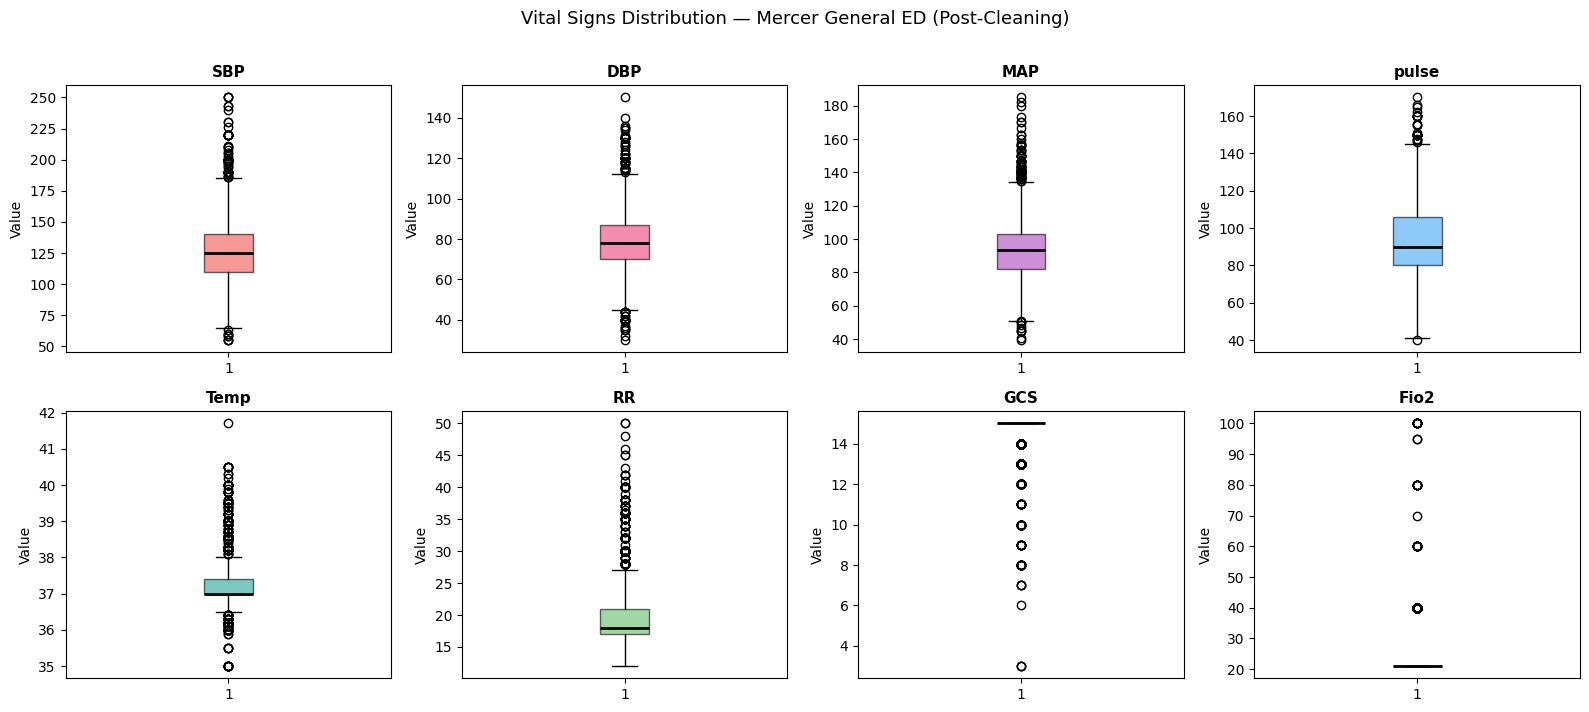

Saved: vitals_boxplots.png


In [49]:
# Box plots for all numeric vitals — side by side for a quick overview
vitals = ['SBP', 'DBP', 'MAP', 'pulse', 'Temp', 'RR', 'GCS', 'Fio2']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

colors = ['#EF5350','#EC407A','#AB47BC','#42A5F5','#26A69A','#66BB6A','#FFA726','#8D6E63']

for i, (vital, col) in enumerate(zip(vitals, colors)):
    axes[i].boxplot(df[vital].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=col, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(vital, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Vital Signs Distribution — Mercer General ED (Post-Cleaning)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('vitals_boxplots.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: vitals_boxplots.png")

### Box Plot Interpretation

The box plots show the spread of each cleaned vital sign and help identify values that may need further review. However, a point appearing outside the whiskers does not automatically mean the value is wrong.

The `Fio2` box plot is a good example. Several points appear above the main box, including values such as `40`, `60`, `80`, and `100`. These may look like statistical outliers because most patients are likely breathing room air at `21%`. However, higher FiO2 values can be clinically valid for patients receiving supplemental oxygen or ventilatory support.

This means the values should not be removed just because they appear as outliers on the box plot. In clinical data, the meaning of the variable must be considered before deciding whether a value is an error.

**Key lesson:** A statistical outlier is not always a data error. Some outliers represent real, clinically important patients.


## 7. Saving and Posting Plots

In [50]:
# Always save plots before posting to Discord or GitHub
# Use dpi=100 for Discord (smaller file), dpi=150 for GitHub README

# Summary: all the plots we created today
import os
plot_files = [f for f in os.listdir('.') if f.endswith('.png')]
print("Plots saved in this session:")
for f in sorted(plot_files):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f:35s} ({size_kb:.0f} KB)")

Plots saved in this session:
  age_vs_pulse.png                    (113 KB)
  gcs_histogram.png                   (35 KB)
  gender_distribution.png             (23 KB)
  pulse_distribution_histogram.png    (39 KB)
  pulse_histogram.png                 (35 KB)
  pulse_vs_map.png                    (161 KB)
  sbp_distribution_histogram.png      (42 KB)
  sbp_vs_dbp.png                      (96 KB)
  vitals_boxplots.png                 (79 KB)


## 8. Student Challenge — Build Your Own Plot

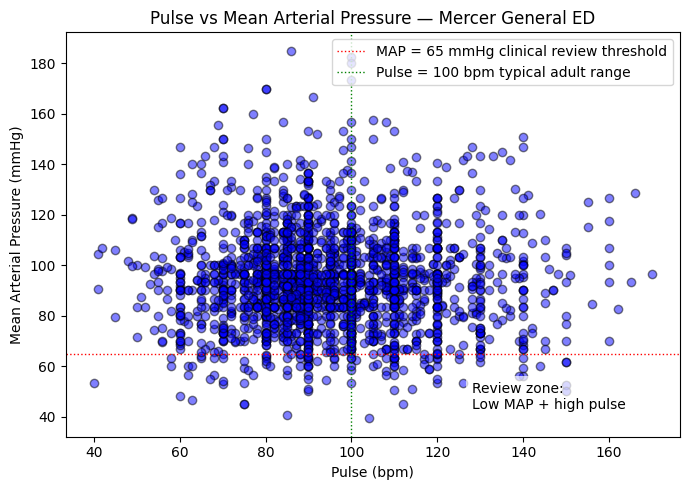

Saved: pulse_vs_map.png


In [51]:
# ── MY TURN ────────────────────────────────────────────────
# Pick any two variables from the dataset and create a meaningful plot.
# Before you code, answer these questions in a comment:
#
# 1. What is the clinical question this plot answers?
# Do patients with lower MAP tend to have higher pulse rates, which may suggest
# possible physiological stress or compensation?

# 2. What type of plot is appropriate (histogram, scatter, bar, box)?
# A scatter plot is most appropriate because the aim is to find the relationship
# between Mean Arterial Pressure (MAP) and pulse, which are both numeric variables.

# 3. What reference lines or annotations would add clinical meaning?
# A horizontal reference line at MAP = 65 mmHg is useful because MAP below this
# level may suggest poor blood flow/perfusion and may require clinical review.
# Also, a vertical reference line at Pulse = 100 bpm is useful to show the upper
# end of the typical resting adult pulse range.
# I will also do an annotation about the review zone

# My Scatter Plot:
# Create Scatter Plot
fig, ax = plt.subplots(figsize=(7, 5))

scatter= ax.scatter(df['pulse'],df['MAP'], alpha=0.5, color='blue',
                     edgecolors='black')

# Create titles and axis labels
ax.set_title('Pulse vs Mean Arterial Pressure — Mercer General ED', fontsize=12)
ax.set_xlabel('Pulse (bpm)')
ax.set_ylabel('Mean Arterial Pressure (mmHg)')

 # Horizontal MAP CLinical Reference line
ax.axhline(y=65, color='red', linestyle=':', linewidth=1, label='MAP = 65 mmHg clinical review threshold')

# Vertical Pulse Clinical Reference line
ax.axvline(x=100, color='green', linestyle=':', linewidth=1, label='Pulse = 100 bpm typical adult range')

# Annotation text to explain the high risk area
ax.text(128, 43, "Review zone:\nLow MAP + high pulse", fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

ax.legend(fontsize=10)

 # Save & display plot
plt.tight_layout()
plt.savefig('pulse_vs_map.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: pulse_vs_map.png")


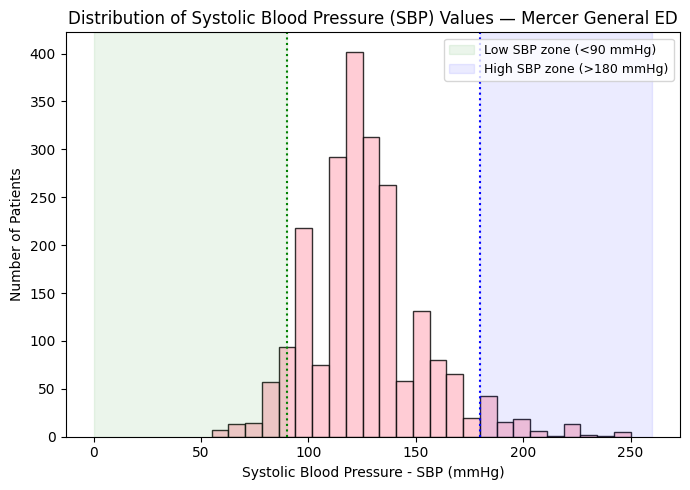

Saved: sbp_distribution_histogram.png


In [52]:
# ── MY TURN ────────────────────────────────────────────────
# Pick any two variables from the dataset and create a meaningful plot.
# Before you code, answer these questions in a comment:
#
# 1. What is the clinical question this plot answers?
# What is the distribution of systolic blood pressure values among patients in the Mercer General
# ED triage dataset?

# 2. What type of plot is appropriate (histogram, scatter, bar, box)?
# A histogram is most appropriate because the aim is to find the distribution of
# SBP within the dataset

# 3. What reference lines or annotations would add clinical meaning?
# Vertical reference lines (upper and lower) for typical adult SBP
# range

# My Histogram:
# Create Histogram
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(df['SBP'], bins=25, edgecolor='black', color='pink', alpha=0.8)

# Create titles and axis titles
ax.set_title("Distribution of Systolic Blood Pressure (SBP) Values — Mercer General ED", fontsize=12)
ax.set_xlabel("Systolic Blood Pressure - SBP (mmHg)")
ax.set_ylabel("Number of Patients")

# Add clinical reference lines for typical adult resting pulse range
ax.axvspan(0, 90, alpha=0.08, color='green', label='Low SBP zone (<90 mmHg)')
ax.axvspan(180, 260, alpha=0.08, color='blue', label='High SBP zone (>180 mmHg)')
ax.axvline(90, color="green", linestyle=":", linewidth=1.5)
ax.axvline(180, color="blue", linestyle=":", linewidth=1.5)

ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("sbp_distribution_histogram.png", dpi=100, bbox_inches="tight")
plt.show()

print("Saved: sbp_distribution_histogram.png")

## 9. Submission Reminder

## Day 3 Submission Summary

For the Day 3 visualization task, this notebook uses `matplotlib` to create clinically meaningful plots from the cleaned Mercer General ED triage dataset.

The submission includes:

- A histogram showing the distribution of a numeric vital sign
- A scatter plot showing the relationship between two clinical variables
- Clear titles and axis labels
- Clinical reference lines or zones where appropriate
- Saved plot images for documentation and submission
- Short interpretations explaining what each plot shows clinically

The goal of this task was not only to create graphs, but to use visualization to answer specific clinical or data questions.

---

### Plotting Quick Reference

| Plot type | When to use | Example code |
|-----------|-------------|--------------|
| Bar chart | To compare categories such as gender, triage level, or clinical flags | `plt.bar(x, y)` |
| Histogram | To show the distribution of one numeric column | `plt.hist(df["col"], bins=N)` |
| Scatter plot | To explore the relationship between two numeric columns | `plt.scatter(df["x"], df["y"])` |
| Box plot | To summarize spread and identify possible outliers | `plt.boxplot(df["col"])` |

Every plot should include a clear title, x-axis label, y-axis label, clinical question, interpretation, and saved image output using `plt.savefig(...)`.